# 01 · Le cadre, et le premier endroit où ça casse : MinT propage le biais

**Bloc 4 · W37, notebook 1 sur 3.** Le bloc 2 a construit MinT. Ce notebook dit **ce qu'il garantit**, et le
premier cas où cette garantie ne suffit plus.

| § | Question | Réponse courte |
|---|---|---|
| 1 | Que garantit `SGS = S` ? | Si les prévisions de base sont non biaisées, les réconciliées le sont aussi. |
| 2 | Que vaut la variance de l'erreur réconciliée ? | $S G W G' S'$, vérifié par simulation. |
| 3 | Et si **une** prévision de base est biaisée ? | MinT répand ce biais sur **toutes** les feuilles. |
| 4 | À partir de quand est-ce grave ? | Un seuil existe : au-delà, MinT fait pire que le bottom-up. |
| 5 | Comment le détecter et le corriger ? | Test de moyenne des résidus, puis débiaiser **avant** de réconcilier. |

> **Comment lire ce notebook.** Les encadrés suivent un code fixe :
> 💡 **Intuition**, l'idée sans les équations · 🧪 **Exemple**, une expérience chiffrée ·
> ⚠️ **Point d'attention**, le piège à éviter · 📌 **À retenir**, le mémo à garder.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from w37_reconciliation import viz
from w37_reconciliation.mint import mint_projection

viz.setup()
pd.set_option("display.precision", 3)
np.set_printoptions(precision=3, suppress=True)
FIG = Path("../figures"); FIG.mkdir(exist_ok=True)
def export(fig, name):
    """Exporte la figure en SVG pour le README et l'article (net en mode sombre)."""
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")

## 1. Le cadre en une page

Les séries observées vérifient $\mathbf y_t = S\,\mathbf b_t$ (feuilles $\mathbf b_t \in \mathbb R^{nb}$, toutes
séries $\mathbf y_t \in \mathbb R^{m}$). Des prévisions de base $\hat{\mathbf y}_h$, produites série par série,
sont **incohérentes**. On les réconcilie linéairement :

$$\tilde{\mathbf y}_h = S\,G\,\hat{\mathbf y}_h \qquad (G \in \mathbb R^{nb \times m})$$

**Condition (i) — absence de biais préservée.** Si $\mathbb E[\hat{\mathbf y}_h] = \mathbb E[\mathbf y_h] = S\boldsymbol\beta$, alors

$$\mathbb E[\tilde{\mathbf y}_h] = SG\,\mathbb E[\hat{\mathbf y}_h] = SGS\,\boldsymbol\beta
\quad\text{vaut}\quad S\boldsymbol\beta \text{ pour tout } \boldsymbol\beta
\iff \boxed{SGS = S}$$

**Condition (ii) — variance de l'erreur réconciliée.** Avec $W = \operatorname{Var}(\mathbf y_h - \hat{\mathbf y}_h)$ et
sous (i), l'erreur réconciliée vaut $\mathbf y_h - \tilde{\mathbf y}_h = SG(\mathbf y_h - \hat{\mathbf y}_h)$
(car $SG\mathbf y_h = SGS\mathbf b_h = \mathbf y_h$), donc

$$\operatorname{Var}(\mathbf y_h - \tilde{\mathbf y}_h) = S\,G\,W\,G'\,S'$$

**MinT** minimise la trace de cette matrice sous la contrainte (i) : $G = (S'W^{-1}S)^{-1}S'W^{-1}$.

> 💡 **Intuition.** Réconcilier, c'est projeter (bloc 2, notebook 03). La contrainte $SGS = S$ dit qu'un vecteur
> **déjà cohérent** n'est pas modifié. Une prévision non biaisée est cohérente « en moyenne », donc elle reste
> non biaisée après projection.

### 🧪 Exemple : vérifier (ii) par simulation

On tire 200 000 vecteurs d'erreurs de base de covariance $W$ connue, on les projette, et on compare la covariance
empirique des erreurs réconciliées à la formule $SGWG'S'$.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


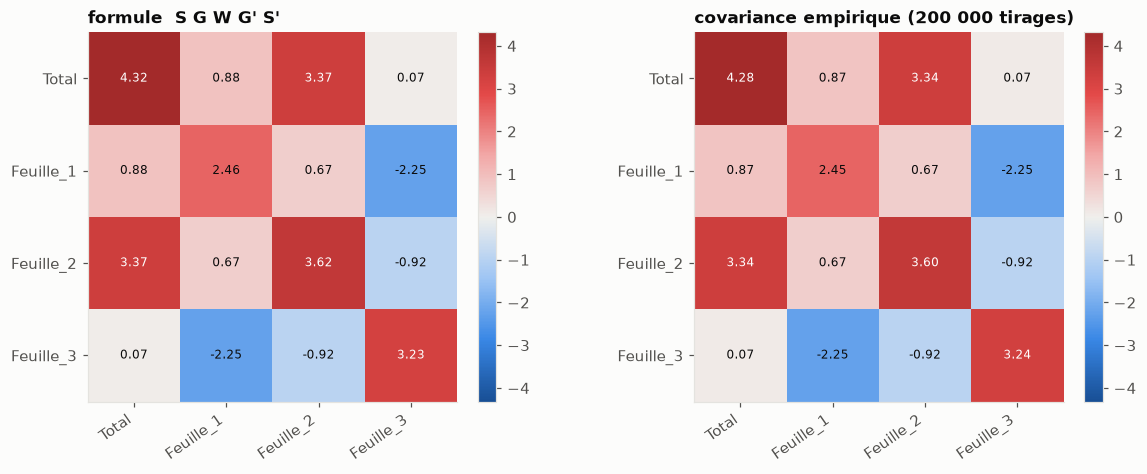

écart max : 0.036   |   trace : base 23.61 → réconciliée 13.63


In [2]:
from w37_reconciliation.fundamentals import toy_hierarchy
S = toy_hierarchy()                                   # 1 total + 3 feuilles
names = ["Total", "Feuille_1", "Feuille_2", "Feuille_3"]
rng = np.random.default_rng(4)
A = rng.normal(size=(4, 4)); W = A @ A.T + np.eye(4)  # une covariance quelconque
G, P = mint_projection(S, W)
err_base = rng.normal(size=(200_000, 4)) @ np.linalg.cholesky(W).T
err_rec = err_base @ P.T
theory, empirical = S @ G @ W @ G.T @ S.T, np.cov(err_rec.T)
fig, axs = plt.subplots(1, 2, figsize=(11, 4.2), layout="constrained")
lim = np.abs(theory).max()
viz.heatmap(axs[0], theory, names, title="formule  S G W G' S'", diverging=True, vmax=lim)
viz.heatmap(axs[1], empirical, names, title="covariance empirique (200 000 tirages)", diverging=True, vmax=lim)
plt.show()
print(f"écart max : {np.abs(theory - empirical).max():.3f}   |   trace : base {np.trace(W):.2f} → réconciliée {np.trace(theory):.2f}")

> 📌 **À retenir — le contrat de MinT.**
> 1. $SGS = S$ ⟺ un vecteur cohérent n'est pas modifié ⟺ l'absence de biais est **préservée**.
> 2. Sous cette contrainte, MinT donne la plus petite variance d'erreur réconciliée.
> 3. Le mot important est *préservée* : MinT ne **crée** pas l'absence de biais.

## 2. Où ça casse n°1 : une seule prévision biaisée contamine tout

Le scénario classique : le national est prévu par un modèle rigide et lissé, alors que les feuilles intègrent les
promotions. Le national est **biaisé**, mais son erreur paraît faible en variance, donc MinT lui fait confiance.

### 🧪 Le contre-exemple du plan

La vérité est $\mathbf b = (10, 20, 30)$, donc total = 60. Les feuilles sont prévues **parfaitement**. Le total est
prévu à 75, soit un biais de +15. $W = \mathrm{diag}(1, 9, 9, 9)$ : le total est réputé 3 fois plus précis (en
écart-type).

In [3]:
from w37_reconciliation.fundamentals import bias_counterexample, bias_allocation
tab = bias_counterexample()
display(tab)
print("erreur absolue totale sur les feuilles — bottom-up :", tab["erreur bottom-up"].iloc[1:].abs().sum(),
      "| MinT :", round(tab["erreur MinT"].iloc[1:].abs().sum(), 3))

,vérité,base,bottom-up,MinT,erreur bottom-up,erreur MinT
Total,60.0,75.0,60.0,74.464,0.0,14.464
Feuille_1,10.0,10.0,10.0,14.821,0.0,4.821
Feuille_2,20.0,20.0,20.0,24.821,0.0,4.821
Feuille_3,30.0,30.0,30.0,34.821,0.0,4.821


erreur absolue totale sur les feuilles — bottom-up : 0.0 | MinT : 14.464


Le bottom-up ignore le total, il ne voit rien. MinT, lui, ajoute **+4,82 à chaque feuille**, alors qu'elles étaient
parfaites, et garde le total à 74,46, presque au niveau biaisé.

### Où part le biais ? La colonne de P

La réconciliation est **linéaire**, donc un biais suit le même chemin qu'une prévision :
$\text{biais réconcilié} = P \times \text{biais de base}$. Un biais de +1 sur le total se répartit selon la
**première colonne de P**.

,part d'un biais de +1 sur le total,pour un biais de +15
Total,0.964,14.464
Feuille_1,0.321,4.821
Feuille_2,0.321,4.821
Feuille_3,0.321,4.821


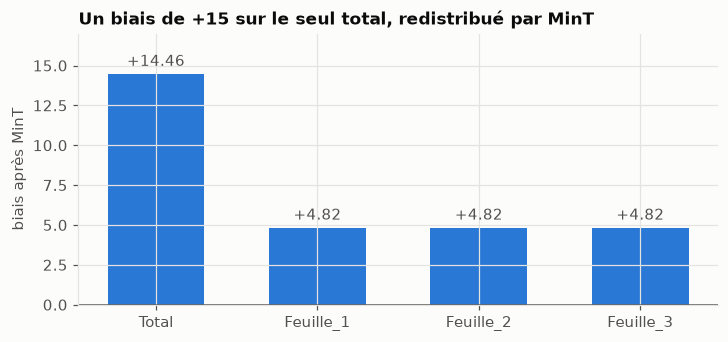

In [4]:
alloc = bias_allocation(S, np.diag([1.0, 9.0, 9.0, 9.0]))
display(pd.DataFrame({"part d'un biais de +1 sur le total": alloc, "pour un biais de +15": 15 * alloc}, index=names))
fig, ax = plt.subplots(figsize=(7.5, 3.2))
bars = ax.bar(names, 15 * alloc, color=viz.BLUE, width=0.6)
ax.bar_label(bars, fmt="%+.2f", padding=3, color=viz.TEXT_2)
ax.axhline(0, color=viz.TEXT_2, lw=1)
ax.set_ylabel("biais après MinT"); ax.set_ylim(0, 17)
ax.set_title("Un biais de +15 sur le seul total, redistribué par MinT")
export(fig, "biais_redistribution"); plt.show()

> 💡 **Intuition.** MinT doit rendre le vecteur cohérent : total = somme des feuilles. Il « fait confiance » au total
> (petite variance dans $W$), donc il le bouge peu et **pousse les feuilles vers le haut** pour combler l'écart.
> Plus on fait confiance à la série biaisée, plus la contamination est forte.

### 🧪 Plus on croit le total, plus les feuilles sont contaminées

On fait varier la variance supposée du total, $W_{\text{total}}$, de 0,1 (confiance aveugle) à 100 (méfiance),
avec des feuilles à 9.

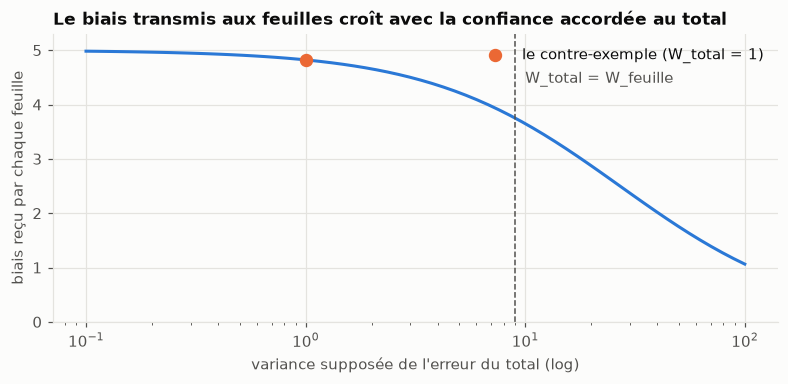

In [5]:
w_tot = np.logspace(-1, 2, 60)
leaf_bias = [15 * bias_allocation(S, np.diag([w, 9.0, 9.0, 9.0]))[1] for w in w_tot]
fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.plot(w_tot, leaf_bias, color=viz.BLUE)
ax.axvline(9, color=viz.TEXT_2, ls="--", lw=1); ax.text(10, 4.4, "W_total = W_feuille", color=viz.TEXT_2)
ax.scatter([1], [15 * bias_allocation(S, np.diag([1.0, 9, 9, 9]))[1]], color=viz.ORANGE, s=60, zorder=3,
           label="le contre-exemple (W_total = 1)")
ax.set_xscale("log"); ax.set_xlabel("variance supposée de l'erreur du total (log)")
ax.set_ylabel("biais reçu par chaque feuille"); ax.set_ylim(0, 5.3)
ax.set_title("Le biais transmis aux feuilles croît avec la confiance accordée au total")
ax.legend(loc="upper right"); plt.show()

## 3. À partir de quand est-ce grave ? Un seuil, pas un tout-ou-rien

Le contre-exemple est déterministe : sans bruit, le bottom-up est parfait. En réalité, les feuilles sont **bruitées**,
et c'est justement pour ça qu'on réconcilie : le total, plus précis, aide les feuilles. On simule donc :

- erreur du total : $\mathcal N(\beta, 1)$, avec un biais $\beta$ qui augmente ;
- erreur de chaque feuille : $\mathcal N(0, 3^2)$, sans biais ;
- MinT avec la **vraie** variance $W = \mathrm{diag}(1, 9, 9, 9)$. Le seul défaut du système est le biais.

On mesure l'erreur absolue moyenne (MAE) par niveau, sur 20 000 tirages.

> ⚠️ **MAE ou MASE ?** Le MASE est un MAE divisé par une échelle propre à chaque série. Au sein d'un même niveau,
> le classement des méthodes est donc identique.

In [6]:
from w37_reconciliation.fundamentals import bias_sweep
sweep = bias_sweep(np.arange(0, 10.01, 0.25))
piv = sweep.pivot(index="biais", columns="méthode")
cross = {lvl: piv[lvl].index[(piv[lvl]["MinT"] > piv[lvl]["bottom-up"]).to_numpy().argmax()]
         for lvl in ["MAE total", "MAE feuilles"]}
display(piv.loc[[0, 2, 4, 5, 6, 8]].round(3))
print("MinT devient pire que le bottom-up à partir d'un biais de :", cross)

MAE total                  MAE feuilles                
méthode      MinT   base bottom-up         MinT  base bottom-up
biais                                                          
0.0         0.786  0.801     4.135        1.967  2.39      2.39
2.0         1.949  2.019     4.135        2.033  2.39      2.39
4.0         3.857  4.000     4.135        2.229  2.39      2.39
5.0         4.822  5.000     4.135        2.372  2.39      2.39
6.0         5.786  6.000     4.135        2.542  2.39      2.39
8.0         7.714  8.000     4.135        2.952  2.39      2.39

MinT devient pire que le bottom-up à partir d'un biais de : {'MAE total': np.float64(4.5), 'MAE feuilles': np.float64(5.25)}


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


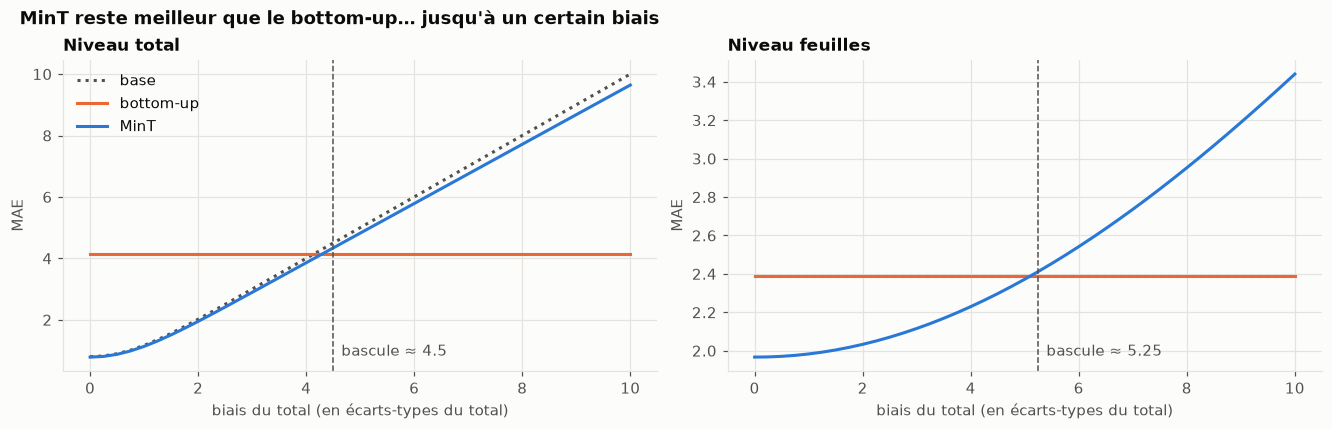

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 3.8), layout="constrained")
for ax, lvl, title in zip(axs, ["MAE total", "MAE feuilles"], ["Niveau total", "Niveau feuilles"]):
    for name, color, ls in [("base", viz.TEXT_2, ":"), ("bottom-up", viz.ORANGE, "-"), ("MinT", viz.BLUE, "-")]:
        ax.plot(piv.index, piv[lvl][name], color=color, ls=ls, label=name)
    ax.axvline(cross[lvl], color=viz.TEXT_2, lw=1, ls="--")
    ax.text(cross[lvl] + 0.15, ax.get_ylim()[0] + 0.05 * np.ptp(ax.get_ylim()), f"bascule ≈ {cross[lvl]:g}",
            color=viz.TEXT_2)
    ax.set_title(title); ax.set_xlabel("biais du total (en écarts-types du total)"); ax.set_ylabel("MAE")
axs[0].legend(loc="upper left")
fig.suptitle("MinT reste meilleur que le bottom-up… jusqu'à un certain biais", x=0.01, ha="left", fontweight="semibold")
export(fig, "biais_seuil"); plt.show()

**Lecture.**

- **Sans biais**, MinT bat le bottom-up aux deux niveaux. C'est le bénéfice normal de la réconciliation : le total
  précis informe les feuilles bruitées.
- **Par rapport au bottom-up**, MinT reste meilleur tant que le biais est modéré. Au-delà d'un biais d'environ 4,5
  (total) et 5,25 (feuilles), il devient **pire aux deux niveaux**.
- **Par rapport aux prévisions de base**, on retrouve la phrase du plan : quand le biais est fort, MinT **améliore**
  légèrement le total (il en corrige une petite partie) et **dégrade** les feuilles.

> ⚠️ **Point d'attention — « amélioré au national, dégradé au SKU » dépend de la baseline.** Comparé aux
> prévisions de base, c'est vrai. Comparé au bottom-up, MinT biaisé finit par perdre **partout**. Dans un rapport,
> nommez toujours la baseline.

## 4. Détecter et corriger : tester le biais **avant** de réconcilier

Le biais se voit dans les **résidus in-sample** : leur moyenne doit être nulle. On applique un test simple à chaque
série, $t = \bar e / (s/\sqrt T)$.

In [8]:
from w37_reconciliation.fundamentals.diagnostics import residual_bias_table
rng = np.random.default_rng(7)
T, beta = 104, 2.0                                       # 2 ans d'historique hebdomadaire, biais de 2 sur le total
sd = np.array([1.0, 3.0, 3.0, 3.0])
E_hist = rng.normal(size=(T, 4)) * sd + np.r_[beta, 0, 0, 0]
display(residual_bias_table(E_hist, names))

,moyenne,écart-type,t,biais suspect
Total,1.913,0.844,23.127,True
Feuille_1,-0.400,2.660,-1.534,False
Feuille_2,-0.337,2.975,-1.156,False
Feuille_3,-0.219,2.939,-0.760,False


In [9]:
# Débiaiser = retirer la moyenne des résidus in-sample de chaque prévision de base, PUIS réconcilier.
bias_hat = E_hist.mean(axis=0)
noise = np.random.default_rng(8).normal(size=(20_000, 4)) * sd
err_base = noise + np.r_[beta, 0, 0, 0]
_, P_mint = mint_projection(S, np.diag(sd**2))
P_bu = S @ np.hstack([np.zeros((3, 1)), np.eye(3)])
rows = {}
for name, e in [("bottom-up", err_base @ P_bu.T), ("MinT sans correction", err_base @ P_mint.T),
                ("MinT après débiaisage", (err_base - bias_hat) @ P_mint.T)]:
    rows[name] = {"MAE total": np.abs(e[:, 0]).mean(), "MAE feuilles": np.abs(e[:, 1:]).mean()}
display(pd.DataFrame(rows).T)

,MAE total,MAE feuilles
bottom-up,4.149,2.399
MinT sans correction,1.941,2.041
MinT après débiaisage,0.784,1.976


Le débiaisage retire l'essentiel de la contamination, et MinT redevient la meilleure option aux deux niveaux. Le
biais résiduel vient de l'estimation de la moyenne sur 104 points.

> ⚠️ **Point d'attention — où débiaiser.** Il faut corriger la **prévision de base** avant la réconciliation, jamais
> la prévision réconciliée après coup : corriger une seule série après coup casse la cohérence.

> 📌 **À retenir — le biais.**
> - MinT **préserve** l'absence de biais, il ne la **crée** pas. Un seul biais se répand selon une colonne de $P$.
> - Plus $W$ fait confiance à la série biaisée, plus la contamination est forte.
> - Il existe un **seuil** : sous un biais modéré, MinT reste utile ; au-delà, il fait pire que le bottom-up.
> - Le réflexe : **tester la moyenne des résidus par niveau, puis débiaiser avant de réconcilier.**
> - Argument commercial : la réconciliation vend la **cohérence**, pas la précision.

→ Notebook **02** : le deuxième endroit où ça casse, les quantiles.